### 0. Importing

Y
1     4255
2     4255
3     4255
4     4255
5     4255
6     4255
7     4255
8     4255
9     4255
10    4255
11    4255
Name: count, dtype: int64
(46805, 49)
(32763, 48) (32763,) (4633, 48) (4633,) (9409, 48) (9409,)


<Axes: >

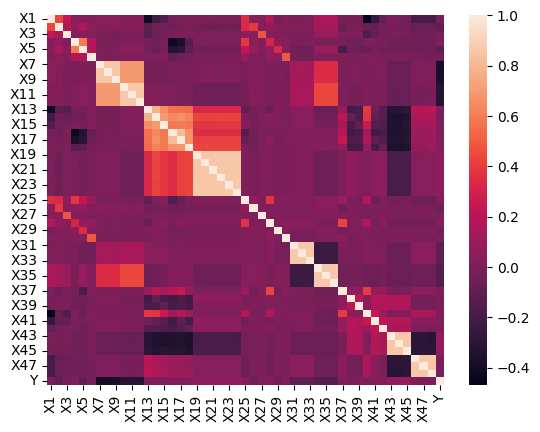

In [17]:
#%pip install statsmodels
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import umap
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv('PartI_dev.csv')
print(df.Y.value_counts()) # We have 11 classes 
print(df.shape)


X = df.drop(columns=['Y'])  # Drop target if present
Y = df['Y']  # Target variable

# 70/20/10 split for train/test/validation

x_train, x_temp, y_train, y_temp = train_test_split(X, Y, stratify=Y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, stratify=y_temp, test_size=0.67, random_state=42)

print(x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape)

# =====================================================================
# Ideally need a multiclass classification model. \
# Start with Multiclass Logistic Regression, then try Random Forest, then try XGBoost??
#
# Pipeline:
# 1. Standardize the data / Encode categorical variables if necessary
# 2. PCA to reduce dimensionality and remove multicollinearity
# 3. Cross-validation to find the best hyperparameters for the model
# 4. Train a Multiclass Logistic Regression model
# 5. Evaluate the model using mean squared error, R^2 score, and other performance metrics.
# 6. Repeat steps 3-5 with Random Forest and XGBoost models, and compare the results.
# =====================================================================
sns.heatmap(df.corr())

## I will be trying two pipelines:
1) Feature engineer based on their VIF score then drops those features when their VIF is >5 corresponding to high correlation to other features, then scale.
2) Standardize and PCA another set this pipeline loses interpretability but it provides benefits for performance and greatest reduction in correlated features

###  1.1 Feature Engineering then measuring correlation


Feature: X1, VIF: 2.589864294954586
Feature: X2, VIF: 1.6530660737830147
Feature: X3, VIF: 1.40830173239773
Feature: X4, VIF: 2.540691199309818
Feature: X5, VIF: 2.0061860857597664
Feature: X6, VIF: 1.3714401025528278
Feature: X7, VIF: 5.136089755019062
Feature 'X7' has high multicollinearity (VIF: 5.14)
Feature: X8, VIF: 5.126169936569871
Feature 'X8' has high multicollinearity (VIF: 5.13)
Feature: X9, VIF: 5.134185246113102
Feature 'X9' has high multicollinearity (VIF: 5.13)
Feature: X10, VIF: 5.402674727675984
Feature 'X10' has high multicollinearity (VIF: 5.40)
Feature: X11, VIF: 5.316094948116141
Feature 'X11' has high multicollinearity (VIF: 5.32)
Feature: X12, VIF: 5.349887750294598
Feature 'X12' has high multicollinearity (VIF: 5.35)
Feature: X13, VIF: 14.54501644877253
Feature 'X13' has high multicollinearity (VIF: 14.55)
Feature: X14, VIF: 13.32382030387284
Feature 'X14' has high multicollinearity (VIF: 13.32)
Feature: X15, VIF: 6.551675425569232
Feature 'X15' has high multic

<Axes: >

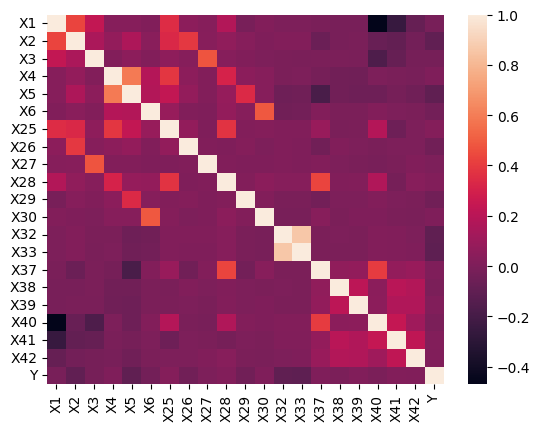

In [18]:

# Based on the heatmap, we can see that there are some features that have
# high correlation with one another, we will need to worry about multicollinearity when we build our model. 
# We can also see that there are some features that have low correlation with the target variable, 
# we may want to consider dropping those features when we build our model.

# PCA will be needed. Now we can use regularization but it will not be as effective as PCA.
# Due to the nature of the correlation matrix, we will need to use PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
removed_table = df.copy()  # Replace with actual feature names to remove
# X should be your feature DataFrame (no target column)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

for i in range(X.shape[1]):
    print(f"Feature: {X.columns[i]}, VIF: {vif_data['VIF'][i]}")
    if vif_data['VIF'][i] > 5:
        print(f"Feature '{X.columns[i]}' has high multicollinearity (VIF: {vif_data['VIF'][i]:.2f})")
        removed_table = removed_table.drop(columns=[X.columns[i]])

print("Remaining features after removing high VIF features:")
print(removed_table.columns)

sns.heatmap(removed_table.corr())

### 1.2 Standardize and PCA

In [ ]:
# =====================================================================
# Scree Plot to determine how many components to use in PCA when building our model. 
# We want to find the number of components that explain at least 95% of the variance in the data.
# =====================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#X = data.drop(columns=['Y'])  # Drop target if present
X_scaled = StandardScaler().fit_transform(X)

pca = PCA().fit(X_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
import matplotlib.pyplot as plt
plt.plot(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(explained_variance >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components_95}")

NameError: name 'data' is not defined

In [35]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('model', KNeighborsClassifier(n_neighbors=30)) # We can try different models here, starting with GaussianNB, then LogisticRegression, then RandomForestClassifier, then XGBClassifier
])

#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
encoder = LabelEncoder()
Y = df['Y']  # Target variable
Y = encoder.fit_transform(Y)  # Encode target variable
# Split your data first
X_train, X_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Evaluate on the test data
y_pred = pipeline.predict(X_test)

print("Number of mislabeled points out of a total %d points : %d"
      % (x_test.shape[0], (y_test != y_pred).sum()))

Number of mislabeled points out of a total 9409 points : 2859


In [36]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6945839119752163
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       851
           1       0.65      0.72      0.68       851
           2       0.63      0.64      0.63       851
           3       0.69      0.74      0.71       851
           4       0.53      0.50      0.52       851
           5       0.50      0.60      0.54       851
           6       0.99      0.96      0.97       851
           7       0.65      0.58      0.61       851
           8       0.70      0.66      0.68       851
           9       0.73      0.61      0.67       851
          10       1.00      1.00      1.00       851

    accuracy                           0.69      9361
   macro avg       0.70      0.69      0.70      9361
weighted avg       0.70      0.69      0.70      9361



In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'y_pred' is not defined

In [10]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

# Fit One-vs-Rest LinearSVC and predict on X
ovr_model = OneVsRestClassifier(LinearSVC(random_state=42),n_jobs=-1)
ovr_model.fit(x_train, y_train)  # X: features, Y: target labels
y_pred = ovr_model.predict(x_test)

# y_pred now contains the predicted class for each sample in X

In [11]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5422467849930918
              precision    recall  f1-score   support

           1       0.40      0.82      0.53       855
           2       0.54      0.40      0.46       855
           3       0.41      0.18      0.25       855
           4       0.51      0.56      0.54       855
           5       0.37      0.23      0.28       856
           6       0.40      0.31      0.35       855
           7       0.87      0.99      0.93       856
           8       0.47      0.39      0.43       856
           9       0.52      0.29      0.37       856
          10       0.46      0.79      0.58       855
          11       0.99      1.00      1.00       855

    accuracy                           0.54      9409
   macro avg       0.54      0.54      0.52      9409
weighted avg       0.54      0.54      0.52      9409



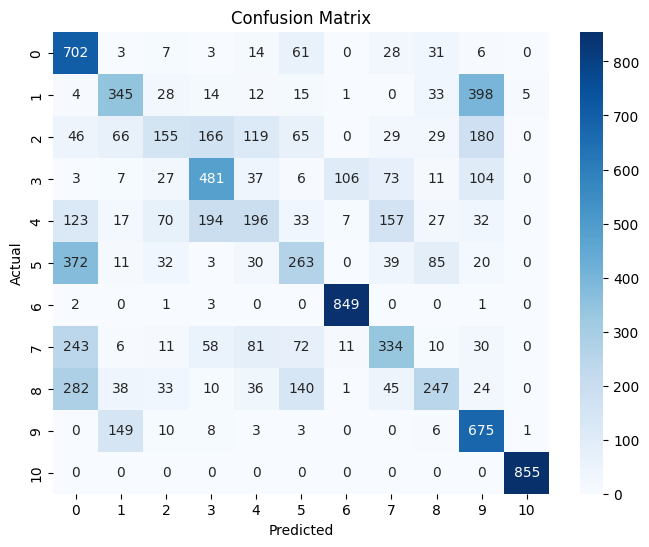

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()